In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

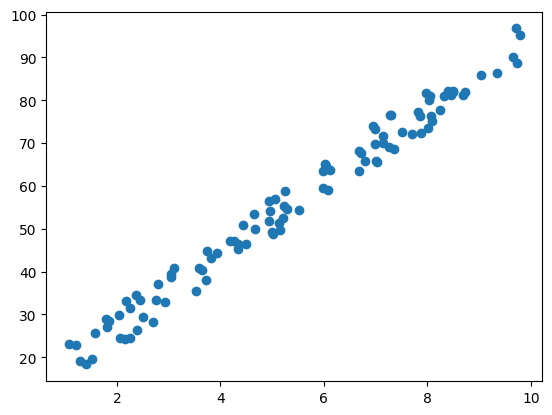

In [2]:
data = pd.read_csv("student.csv")
plt.scatter(data.studytime, data.score)

In [ ]:
def loss_function(m, b, points):
    total_error=0
    for i in range(len(points)):
        x = points.iloc[i].studytime
        y = points.iloc[i].score      
        total_error += (y - (m * x + b)) ** 2
    total_error / float(len(points))         

In [ ]:
def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0
    n = len(points)
    
    for i in range(n):
        x = points.iloc[i].studytime
        y = points.iloc[i].score
        
        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))
        
    m = m_now - (m_gradient * L)    
    b = b_now - (b_gradient * L) 
    return m, b

In [ ]:
m = 0
b = 0
L = 0.001
epochs = 3000
for i in range(epochs):
    m,b = gradient_descent(m,b,data, L)
    print(m,b)
print(m,b)
plt.scatter(data.studytime, data.score, color="black")
plt.plot([data.studytime.min(), data.studytime.max()], 
         [m * data.studytime.min() + b, m * data.studytime.max() + b], 
         color="red")
plt.show()

In [ ]:
score = m * 7.5 + b
print(score)       

In [ ]:
def compute_cost(x,y,w,b):
    m= x.shape[0]
    cost=0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (y[i] - f_wb) **2
    total_cost= (1/2*m) * cost
    return total_cost
    

In [ ]:
compute_cost(data.studytime,data.score, 3,0.2)

In [ ]:
def gradient_descent(x,y,w_now,b_now, a):
    
    w_gradient=0
    b_gradient=0
    m= len(x)
    for i in range(m):
        f_wb= w_now * x[i] + b_now
        w_gradient += (1/m) * (f_wb - y[i]) * x[i]
        b_gradient += (1/m) * (f_wb - y[i])
    w= w_now -(w_gradient * a)
    b= b_now -(b_gradient * a)
    
    return w,b

In [ ]:
w = 0
b = 0
a =0.0001
epochs = 3000

for i in range(epochs):
    w, b = gradient_descent(data.studytime, data.score, w, b, a)
    # Print occasionally to keep the console clean
    if i % 500 == 0:
        print(f"Epoch {i}: w={w:.4f}, b={b:.4f}")
    
print(f"Final Result: w={w:.4f}, b={b:.4f}")

# Plotting the data
plt.scatter(data.studytime, data.score, color="black", label="Actual Data")

# Plotting the prediction line
x_range = [data.studytime.min(), data.studytime.max()]
y_range = [w * x_range[0] + b, w * x_range[1] + b]
plt.plot(x_range, y_range, color="red", label="Regression Line")

plt.xlabel("Study Time")
plt.ylabel("Score")
plt.legend()
plt.show()


In [ ]:
# 1. Get predictions from your trained w and b
y_pred = w * data.studytime + b 

# 2. Calculate the average of the actual scores
y_mean = data.score.mean()

# 3. Sum of Squared Residuals (How much your model missed)
ss_res = ((data.score - y_pred) ** 2).sum()

# 4. Total Sum of Squares (How much the data varies naturally)
ss_tot = ((data.score - y_mean) ** 2).sum()

# 5. R-squared Formula
r2 = 1 - (ss_res / ss_tot)

print(f"Percentage of correctness (R2): {r2 * 100:.2f}%")


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare original data (dropping target leakage columns)
X_raw = df.drop(columns=["date", "orders", "completed_orders", "canceled_orders"])
y = df["orders"].values

# Compute scaling parameters from training data
X_mean = X_raw.mean()
X_std = X_raw.std()
X_scaled = np.array((X_raw - X_mean) / X_std)

# 2. Optimized functions
def compute_loss(X, y, w, b):
    return np.mean((np.dot(X, w) + b - y) ** 2)

def gradient_descent_step(X, y, w_now, b_now, alpha):
    num_samples = len(y)
    error = (np.dot(X, w_now) + b_now) - y
    w_gradient = (1 / num_samples) * np.dot(X.T, error)
    b_gradient = (1 / num_samples) * np.sum(error)
    return w_now - (alpha * w_gradient), b_now - (alpha * b_gradient)

# 3. Model Training Loop
w = np.zeros(X_scaled.shape[1])
b = 0.0
alpha = 0.01
epochs = 1000
loss_history = []

for i in range(epochs):
    w, b = gradient_descent_step(X_scaled, y, w, b, alpha)
    loss_history.append(compute_loss(X_scaled, y, w, b))

# 4. Generate Predictions on New Data
# Imagine tomorrow is Saturday (6), weekend (1), 600 users, 25 restaurants, active promo (1)
new_data_point = pd.DataFrame([{
    "weekday": 6,
    "is_weekend": 1,
    "active_users": 600,
    "restaurants": 25,
    "promotion": 1
}])

# CRITICAL: Scale the new data using original mean and standard deviation
new_data_scaled = np.array((new_data_point - X_mean) / X_std)

# Compute final prediction using optimized weights
predicted_orders = np.dot(new_data_scaled, w) + b

print(f"--- Prediction Results ---")
print(f"New Sample Data Input:\n{new_data_point.to_string(index=False)}")
print(f"Predicted Total Orders: {predicted_orders[0]:.2f}\n")

# 5. Plot the Training History
plt.figure(figsize=(9, 5))
plt.plot(range(epochs), loss_history, color='#1f77b4', linewidth=2.5, label='Loss (MSE)')
plt.title('Cost Function Optimization History', fontsize=12, fontweight='bold')
plt.xlabel('Epochs (Iterations)', fontsize=10)
plt.ylabel('Mean Squared Error', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


NameError: name 'df' is not defined

In [1]:
print(max(3,5))

5
